## 8-10. 텍스트 분석 실습 - 캐글 Mercari Price Suggestion Challenge
Mercari Price Suggestion Challenge는 캐글에서 진행된 Challenge로서, 일본의 대형 온라인 쇼핑 
몰인 Mercari사의 제품에 대해 가격을 예측하는 과제입니다. 제공되는 데이터 세트는 제품에 대한 여 
러 속성 및 제품 설명 등의 텍스트 데이터로 구성됩니다. Mercari사는 이러한 데이터를 기반으로 제품 
예상 가격을 판매자들에게 제공하고자 합니다. 이와 같은 프로세스를 구현하기 위해 판매자는 제품명, 
브랜드 명, 카테고리, 제품 설명 등 다양한 속성 정보를 입력하게 되고, ML 모델은 이 속성에 따라 제 
품의 예측 가격을 판매자에게 자동으로 제공할 수 있습니다.
제공되는 데이터 세트의 속성은 다음과 같습니다.
- train_id： 데이터 id
- name： 제품명
- item_conditionjd： 판매자가 제공하는 제품 상태
- category_name： 카테고리 명
- brand_name： 브랜드 이름
- price： 제품 가격. 예측을 위한 타깃 속성
- shipping： 배송비 무료 여부. 1 이면 무료(판매자가 지불), 0이면 유료(구매자 지불)
- item_description： 제품에 대한 설명

이들 중 price가 예측해야 할 타깃 값입니다. 회귀로 피처를 학습한 뒤 price를 예측하는 문제입니다. 
이번 Mercari Price Suggestion이 기존 회귀 예제와 다른 점은 item_description과 같은 텍스트 형 
태의 비정형 데이터와 다른 정형 속성을 같이 적용해 회귀를 수행한다는 점입니다.

### 데이터 전처리
먼저 필요한 라이브러리와 함께 mercari_train.tsv 데이터를 DataFrame으로 로딩하고, 데이터를 간략하게 살펴보겠습니다.

In [ ]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer 
import pandas as pd
mercari_df= pd.read_csv('C:/Users/User/OneDrive/바탕 화면/mercari_train.tsv', sep='\t') 
print(mercari_df.shape) 
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


1482535개의 레코드를 가지고 있는 데이터 세트입니다. 다음으로 피처의 타입과 Null 여부를 확인하 
겠습니다.

In [ ]:
print(mercari_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB
None


brand_name 칼럼의 경우 매우 많은 Null 값을 가지고 있습니다. 전체 1482535건 중에 849853건 
만 Not null입니다. brand_name은 가격에 영향을 미치는 중요 요인으로 판단되지만, 많은 데이 
터가 Null로 돼 있습니다. category_name은 악= 6300건의 null 데이터를 가지고 있습니다. item_ 
desciption의 null 값은 4건으로 미비합니다. 이 Null 데이터는 이후에 적절한 문자열로 치환하겠습 
니다.
Target 값인 price 칼럼의 데이터 분포도를 살펴보겠습니다. 회귀에서 Target 값의 정규 분포도는 매 
우 중요합니다. 왜곡돼 있을 경우 보통 로그를 씌워서 변환하면 대부분 정규 분포의 형태를 가지게 됩 
니다. 먼저 price 칼럼의 데이터 값 분포도를 확인해 보겠습니다.

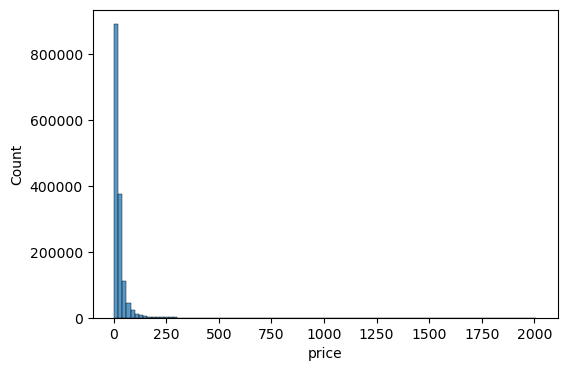

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_df = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df, bins=100) 
plt.show()

price 값이 비교적 적은 가격을 가진 데이터 값에 왜곡돼 분포돼 있습니다. Price 칼럼을 로그 값으로 
변환한 뒤 분포도를 다시 살펴보겠습니다.

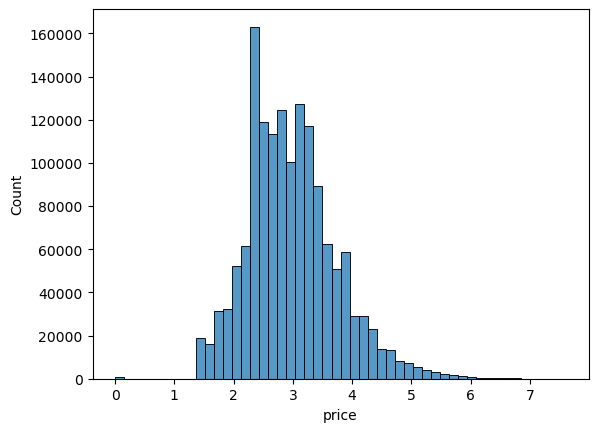

In [8]:
import numpy as np
y_train_df = np.log1p(y_train_df) 
sns.histplot(y_train_df, bins=50) 
plt.show()

로그 값으로 변환하면 price 값이 비교적 정규 분포에 가까운 데이터를 이루게 됩니다. 데이터 세트의 
price 칼럼을 원래 값에서 로그로 변환된 값으로 변경하겠습니다.

In [9]:
mercari_df['price'] = np.log1p(mercari_df['price']) 
mercari_df['price'].head(3)

0    2.397895
1    3.970292
2    2.397895
Name: price, dtype: float64

다른 피처의 값도 살펴보겠습니다. shipping과 item_condition_id 값의 유형은 다음과 같습니다

In [11]:
print('Shipping 값 유형:\n', mercari_df['shipping'].value_counts())
print ('item_condition_id 값 유형: \n', mercari_df ['item_condition_id' ].value_counts())

Shipping 값 유형:
 shipping
0    819435
1    663100
Name: count, dtype: int64
item_condition_id 값 유형: 
 item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64


Shipping 칼럼은 배송비 유무이며, 값이 비교적 균일합니다. Item_condition_id는 판매자가 제공하 
는 제품 상태로서 각 값이 의미하는 바는 캐글에 기재돼 있지 않아서 알 수 없지만, 1, 2, 3 값이 주를 
이루고 있습니다.
item_description 칼럼은 Null 값은 별로 없지만, description에 대한 별도 설명이 없는 경우 ‘No 
description yet’ 값으로 돼 있습니다. 이러한 값이 얼마나 있는지 알아보겠습니다.

In [13]:
boolean_cond= mercari_df['item_description']== 'No description yet' 
mercari_df[boolean_cond]['item_description'].count()

np.int64(1482535)

item_description이 ‘No description yet'로 돼 있는 로우는 82489건입니다. "No description yet’ 
의 경우도 Null과 마찬가지로 의미 있는 속성값으로는 사용될 수 없으므로 적절한 값으로 변경해야 합 
니다.
category_name을 살펴보겠습니다. categoryjname은 7’로 분리된 카테고리를 하나의 문자열로 나 
타내고 있습니다. 가령 ‘Men/Tops/T—shirts’는 대분류 ‘Men’, 중분류 “Tops’, 소분류 "T-shirts’로 나 
눌 수 있습니다. category_name은 텍스트이므로 피처 추출 시 tokenizer를 /로 하여 단어를 분리해 
벡터화할 수도 있습니다만, 여기서는 category_name의 /를 기준으로 단어를 토큰화해 각각 별도의 
피처로 저장하고 이를 이용해 알고리즘을 학습시키겠습니다.
category_name 칼럼을 7’를 기준으로 대, 중, 소분류를 효과적으로 분리해 내기 위해 별도의 split_ 
cat() 함수를 생성하고 이를 DataFrame의 apply lambda 식에 적용하겠습니다. category name 칼 
럼은 Null값을 약 6300여 건을 가지고 있으므로 이에 유의하면서 분리를 해내야 합니다. split_cat() 
함수를 간략히 살펴보면, 먼저 category_name 이 Null 이 아닌 경우에 split('/') 를 이용해 대, 중, 소 
분류를 분리합니다. 파이썬은 문자열에 split(tokenizer문자) 함수를 호출하면 tokenizer 문자에 따 
라 문자열을 분리해 리스트로 반환합니다. 만일 category name이 Null일 경우에는 split( ) 함수가 
Error를 발생하므로 이 Error를 except catch하여 대, 중, 소 분류 모두 ‘Other Null’ 값을 부여합니다. 
대, 중, 소 칼럼은 mercari_df에서 cat_dae, catjung, cat_so로 부여하겠습니다. 한 가지 고민해야 
할 점은 판다스의 apply lambda로 반환되는 데이터 세트가 리스트를 요소로 가지고 있는데, 이를 다 
시 cat_dae, catjung, cat_so의 DataFrame 칼럼으로 분리해야 하는 것입니다. 이 부분은 다음 코드 
에서처럼 zip과 *를 apply lambda 식에 적용하면 여러 개의 칼럼으로 간단하게 분리할수 있습니다.

In [14]:
# apply 1ambda에서 호출되는 대, 중, 소 분할 함수 생성, 대, 중, 소 값을 리스트로 반환 
def split_cat(category_name):
    try:
        return category_name.split('/')
    except:
        return ['Other_Null', '0ther_Null', 'Other_Null']

# 위의 split_cat( )을 apply lambda에서 호출해 대, 중, 소 칼럼을 mercari_df에 생성.
mercari_df ['cat_dae'], mercari_df ['cat_jung'], mercari_df ['cat_so'] = zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))

# 대분류만 값의 유형과 건수를 살펴보고, 중분류, 소분류는 값의 유형이 많으므로 분류 개수만 추출 
print('대분류 유형:\n', mercari_df['cat_dae'].value_counts())
print('중분류 개수:', mercari_df[ 'cat_jung' ].nunique())
print('소분류 개수:', mercari_df['cat_so'].nunique())

대분류 유형:
 cat_dae
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Other_Null                  6327
Name: count, dtype: int64
중분류 개수: 114
소분류 개수: 871


대분류의 경우 Women, Beauty, Kids 등의 분류가 매우 많습니다. 중분류 유형은 114개, 소분류는 
817개로구성돼있습니다.
마지막으로 brand_name, category name, item_description 칼럼의 Null 값은 일괄적으로 ‘Other 
Null’로 동일하게 변경하겠습니다. brand_name은 price 값 결정에 영향을 많이 줄 것으로 판단되지 
만, Null 값이 매우 많습니다. 아쉽게도 이 Null 값을 다른 값으로 변경하는 것은 적절하지 않을 것으 
로 판단되므로 일괄적으로 ‘Other_Null’로 변경하겠습니다. fillna()를 적용한 뒤에 각 칼럼별로 Null 
값이 없는지 다음과 같이 mercari_df.isnull( ).sum()을 호출해 확인하면 모든 칼럼에서 Null 건수가 
0 임을 알수 있습니다.

In [15]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')

# 각 칼럼별로 Null 값 건수 확인. 모두 0이 나와야 합니다.
mercari_df.isnull().sum()

train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
cat_dae              0
cat_jung             0
cat_so               0
dtype: int64

데이터 클린징 작업은 이 정도 수준까지만 진행하겠습니다. 다음으로는 칼럼을 숫자형 코드 값으로 인 
코딩하고, 텍스트형 칼럼에 대해서는 피처 벡터화 변환을 적용하겠습니다.

### 피처 인코딩과 피처 벡터화

Mercari Price Suggestion에 이용되는 데이터 세트는 문자열 칼럼이 많습니다. 이 문자열 칼럼 중 레 
이블 또는 원-핫 인코딩을 수행하거나 피처 벡터화로 변환할 칼럼을 선별해 보겠습니다. 먼저 이 피 
처를 어떤 방식으로 변환할지 검토한 후에 추후에 일괄적으로 전체 속성의 변환 작업을 적용하겠습니 
다. Mercari Price Suggestion에서 예측 모델은 price 값, 즉 상품 가격을 예측해야 하므로 회귀 모델 
을 기반으로 합니다. 선형 회귀 모델과 회귀 트리 모델을 모두 적용할 예정이며, 특히 선형 회귀의 경우 
원-핫 인코딩 적용이 훨씬 선호되므로 인코딩할 피처는 모두 원-핫 인코딩을 적용하겠습니다. 피처 
벡터화의 경우는 비교적 짧은 텍스트의 경우는 Count 기반의 벡터화를, 긴 텍스트는 TD-IDF 기반의 
벡터화를 적용하겠습니다.첫 번째로 검토할 칼럼은 brand_name입니다. brand_name 칼럼은 상품의 브랜드명입니다(상품명이 아닙니다). 상품 브랜드명이 어떤 유형으로 돼 있는지 유형 건수와 대표적인 브랜드명을 5개 정도만 살펴보겠습니다.

In [16]:
print('brand name 의 유형 건수:', mercari_df['brand_name'].nunique())
print('brand name sample 5건:', mercari_df['brand_name'].value_counts()[:5])

brand name 의 유형 건수: 4810
brand name sample 5건: brand_name
Other_Null           632682
PINK                  54088
Nike                  54043
Victoria's Secret     48036
LuLaRoe               31024
Name: count, dtype: int64


brand_name의 경우 대부분 명료한 문자열로 돼 있습니다. 별도의 피처 벡터화 형태로 만들 필요 없 
이 인코딩 변환을 적용하면 됩니다. brand_name의 종류가 4810건으로 원-핫 인코딩으로 변환하기 
에 다소 많아 보이나 본 예제의 ML 모델 구축상 큰 문제는 없습니다. brand_name은 원-핫 인코딩 변 
환하겠습니다. 다음으로 상품명을 의미하는 name 속성이 어떤 유형으로 돼 있는지 유형 건수와 상 
품명을 7개만 출력해 보겠습니다.

In [21]:
print('name 의 종류 개수:', mercari_df['name'].nunique()) 
print('name sample 7건: \n', mercari_df['name'][: 7])

name 의 종류 개수: 1225273
name sample 7건: 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


상품명은 name 속성의 경우 종류가 매우 많습니다. 무려 1,225,273가지입니다. 전체 데이터가 
1,482,535개이므로 개별적으로 거의 고유한 상품명을 가지고 있습니다. Name 속성은 유형이 매우 
많고, 적은 단어 위주의 텍스트 형태로 돼 있으므로 Count 기반으로 피처 벡터화 변환을 적용하겠습 
니다.
category_name 칼럼은 이전에 전처리를 통해서 해당 칼럼은 대, 중, 소 분류 세 개의 칼럼인 cat_ 
dae, catjung, cat_so 칼럼으로 분리됐습니다. cat_dae, catjung, cat_so 칼럼도 원一핫 인코딩을 
적용하겠습니다.
shipping 칼럼은 배송비 무료 여부로서 0과 1, 두 가지 유형의 값을 가지고 있으며 item_condition_ 
id는 상품 상태로서 1, 2, 3, 4, 5의 다섯 가지 유형의 값을 가지고 있습니다. 이 두 칼럼 모두 원-핫 인 
코딩을 적용하겠습니다. 다음으로 item_description입니다. Item_description은 상품에 대한 간단 설명으로 데이터 세트에서 
가장 긴 텍스트를 가지고 있습니다. 해당 칼럼의 평균 문자열 크기와 2개 정도의 텍스트만 추출해 보겠 
습니다.

In [24]:
pd.set_option('max_colwidth', 200)

# item_description의 평균 문자열 크기 
print('item_description 평균 문자열 크기:', mercari_df['item_description'].str.len().mean())

mercari_df['item_description'][:2]

item_description 평균 문자열 크기: 18.0


0    No description yet
1    No description yet
Name: item_description, dtype: object

평균 문자열이 145자로 비교적 크므로 해당 칼럼은 TF-IDF로 변환하겠습니다.
이제 주요 칼럼을 인코딩 및 피처 벡터화 변환해 보겠습니다. 먼저 name과 item_description 칼럼을 
피처 벡터화합니다. name 칼럼의 경우는 CountVbctorizer로, item_description 칼럼은 TfidfVecto 
rizer로 변환하겠습니다. CountViectorizer는 기본 파라미터로, TfidfWctorizer는 max features = 
50000으로 제한하고 n_gram은 triple gram인 ngram_range=(1,3), stop_words는 english로 설정 
합니다.

In [26]:
# name 속성에 대한 피처 벡터화 변환 
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df.name)

# item_description에 대한 피처 벡터화 변환
tfidf_descp = TfidfVectorizer(max_features = 50000, ngram_range= (1, 3), stop_words='english') 
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])
print('name vectorization shape:', X_name.shape)
print('item_description vectorization shape:', X_descp.shape)

name vectorization shape: (1482535, 105757)
item_description vectorization shape: (1482535, 1)


CountVectorizer, TfidfVectorizer가 fit_transform()을 통해 반환하는 데이터는 희소 행렬 형태입니 
다. 희소 행렬 객체 변수인 X_name과 X_descp를 새로 결합해 새로운 데이터 세트로 구성해야 하고, 
앞으■로 인코딩될 cat dae, catjung, cat_so, brand_name, shipping, item_condition_id도 모두 
X_name, X_descp와 결합돼 ML 모델을 실행하는 기반 데이터 세트로 재구성돼야 합니다.
이를 위해서 이 인코딩 대상 칼럼도 밀집 행렬 행태가 아닌 희소 행렬 형태로 인코딩을 적용한 뒤, 함 
께 결합하도록 하겠습니다. 사이킷런은 원一핫 인코딩을 위해 OneHotEncoder와 LabelBinarizer 클 
래스를 제공합니다. 이 중 LabelBinarizer 클래스는 희소 행렬 형태의 원-핫 인코딩 변환을 지원합 
니다. 생성 시 sparse_out=True로 파라미터를 설정해주기만 하면 됩니다. 모든 인코딩 대상 칼럼은 
LabelBinarizer를 이용해 희소 행렬 형태의 원-핫 인코딩으로 변환하겠습니다. 개별 칼럼으로 만들어 
진 희소 행렬은 사이파이 패키지 sparse 모듈의 hstack( ) 함수를 이용해 결합하겠습니다. hstack( ) 
함수는 희소 행렬을 손쉽게 칼럼 레벨로 결합할 수 있게 해줍니다.

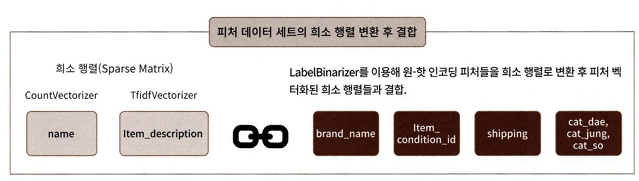

먼저 인코딩 대상 칼럼을 모두 LabelBinarizer로 원-핫 인코딩 변환하겠습니다. 다음 예제 코드는 저 
자의 PC에서 약 5분 정도의 시간이 소모됩니다

In [ ]:
from sklearn.preprocessing import LabelBinarizer

# brand-name, item_condition_id, shipping 각 피처들을 희소 행렬 원-핫 인코딩 변환 
lb_brand_name= LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name']) 
lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id']) 
lb_shipping= LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

# cat_dae, cat Jung, cat_so 각 피처들을 희소 행렬 원-핫 인코딩 변환 
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae= lb_cat_dae.fit_transform(mercari_df['cat_dae']) 
lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df ['cat_jung']) 
lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

NameError: name 'mercari_df' is not defined

제대로 변환됐는지 생성된 인코딩 데이터 세트의 타입과 shape을 살펴보겠습니다

In [ ]:
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand shape:{0}, X_item_cond_id shape:{l}'.format(X_brand.shape, X_item_cond_id.shape)) 
print('X_shipping shape:{0}, X_cat_dae shape:{1}'.format(X_shipping.shape, X_cat_dae.shape)) 
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

인코딩 변환된 데이터 세트가 CSR 형태로 변환된 csr_matrix 타입입니다. 그리고 brand_name 칼럼 
경우 값의 유형이 4810개이므로 이를 원一핫 인코딩으로 변환한X_brand_shape의 경우 4810개의 인 
코딩 칼럼을 가지게 되었습니다. X_cat_so의 경우도 마찬가지로 8기개의 인코딩 칼럼을 가집니다. 인 
코딩 칼럼이 매우 많이 생겼지만, 피처 벡터화로 텍스트 형태의 문자열이 가지는 벡터 형태의 매우 많 
은 칼럼과 함께 결합되므로 크게 문제 될 것은 없습니다. 이번에는 앞에서 피처 벡터화 변환한 데이터 세트와 희소 인코딩 변환된 데이터 세트를 hstack()을 이용해 모두 결합해 보겠습니다. 결합된 데이터는 Mercari Price Suggestion을 위한 기반 데이터 세트로 사용되는데, 여기서는 결합한 데이터의 타입과 크기만 확인하고 메모리에서 삭제하도록 하겠습니다. 만들어진 결합 데이터가 비교적 많은 메모리를 잡아먹기 때문에 개인용 PC에서 메모리 오류가 발생할 수 있기에 del ‘객체 변수명’과 gc.collect()로 결합 데이터를 메모리에서 삭제합니다. 추후에 다양한 모델을 적용하므로 그때마다 다시 결합해 해당 데이터 세트를 이용하도록 하겠습니다.

In [ ]:
from scipy.sparse import hstack 
import gc

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# hstack 함수를 이용해 인코딩과 벡터화를 수행한 데이터 세트를 모두 결합.
X_features_sparse= hstack(sparse_matrix_list).tocsr() 
print(type(X_features_sparse), X_features_sparse.shape)

# 데이터 세트가 메모리를 많이 차지하므로 사용 목적이 끝났으면 바로 메모리에서 삭제. 
del X_features_sparse 
gc.collect()

### 릿지 회귀 모델 구축 및 평가